# Notebook exploring outliers using pyod

In [1]:
from pyod.models.knn import KNN   # kNN detector
from helpers.dataframeBuilder import get_df_neigbours_answer_for_all_itemIDs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from emmv import emmv_scores

pd.set_option("display.max_columns", None)
TRESHOLD_pyod_majority_vote = 0.7

from sklearn.preprocessing import MinMaxScaler

pyodbc using linux/docker


In [2]:
LOTS_OF_TRAINING_TIME = False # Run all
RUN_OPTIONAL = False # Just skip a few

## LOF is proximity based

So anything that has to do with distances
In that aspect, I believe using the exented matrix is good

In [ ]:
from pyod.models.copod import COPOD # Don't use
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IForest
# from pyod.models.ae1svm import AE1SVM
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.dif import DIF


In [4]:
df, df_test, df_question = get_df_neigbours_answer_for_all_itemIDs()

/home/miked/code/dep2-g2/anomalies/helpers/dataframeBuilder.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT FCATestKey, f.CandidateKey as CandidateKey, CreatedDateKey, TestStartTimeKey, TestFinishTimeKey, VersionNumber, c.InstanceID as InstanceID FROM FactTestFCA f JOIN DimCandidate c ON c.CandidateKey = f.CandidateKey", con)
/home/miked/code/dep2-g2/anomalies/helpers/dataframeBuilder.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_question = pd.read_sql("SELECT FCAQuestionKey, FCATestKey, ItemID, AnswerSequence1, AnswerSequence2, AnswerSequence3, TimeSpent FROM FactQuestionFCA", con)


Index(['Q117_A1', 'Q117_A2', 'Q117_A3', 'Q118_A1', 'Q118_A2', 'Q118_A3',
       'Q119_A1', 'Q119_A2', 'Q119_A3', 'Q120_A1',
       ...
       'Q446_A2', 'Q446_A3', 'Q447_A1', 'Q447_A2', 'Q447_A3', 'DaysAgo',
       'HoursAgo', 'InstanceID', 'FCATestKey', 'VersionNumber'],
      dtype='object', length=662)


In [5]:
df_test

,FCATestKey,CandidateKey,CreatedDateKey,TestStartTimeKey,TestFinishTimeKey,VersionNumber,InstanceID,FinishDateTime,year,DaysAgo,HoursAgo
0,50891,1668403,2017-06-08,70745,74101,v1.0,3,2017-06-08 07:41:01,2017,2724,65358
1,48924,3025673,2021-01-13,213614,223606,v1.0,3,2021-01-13 22:36:06,2021,1409,33783
2,60687,3028213,2021-01-18,192248,201513,v1.0,3,2021-01-18 20:15:13,2021,1404,33665
3,131732,3034523,2021-01-24,64901,72033,v1.0,3,2021-01-24 07:20:33,2021,1398,33534
4,60733,3034883,2021-01-22,152456,161238,v1.0,3,2021-01-22 16:12:38,2021,1400,33573
...,...,...,...,...,...,...,...,...,...,...,...
160062,77512,45340141,2022-01-30,134114,141607,v1.0,1,2022-01-30 14:16:07,2022,1027,24623
160063,93093,45340181,2022-01-26,210158,212018,v1.0,1,2022-01-26 21:20:18,2022,1031,24712
160064,94695,45340261,2022-01-30,103307,110447,v1.0,1,2022-01-30 11:04:47,2022,1027,24626
160065,100658,45341041,2022-02-13,195218,201455,v1.0,1,2022-02-13 20:14:55,2022,1013,24281


In [6]:
df

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [7]:
outliers = {}
proba = {}

In [8]:
scaler = MinMaxScaler()

scaler.fit(df)

MinMaxScaler()

In [9]:
df = pd.DataFrame(scaler.transform(df), columns=df.columns)
df

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

## Local Outlier Factor

In [10]:
model = LOF(contamination=0.05)

model.fit(df)

# Predict the outliers (1 means outlier, 0 means inlier)
outliers["lof"] =  model.predict(df)
proba["lof"] = model.predict_proba(df)[:,1]
outliers["lof"]

array([1, 1, 1, ..., 0, 0, 0])

In [11]:
# Add the outlier prediction to the DataFrame
# emmv_lof = emmv_scores(lof, df, n_generated=len(df))
# emmv_lof

In [12]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='manhattan', contamination=0.05)
    model.fit(df)
    outliers["lof_manhattan"] = model.predict(df)
    proba["lof_manhattan"] = model.predict_proba(df)[:,1]
    outliers["lof_manhattan"]


In [13]:
# lof_outliers2

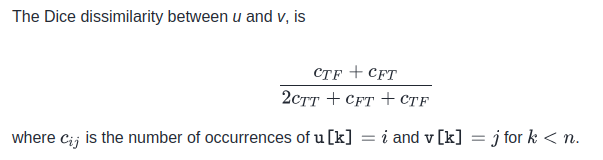
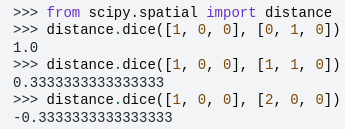
I don't get the distance, but it seems different

In [14]:
# minimum 90 minutes
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='dice', contamination=0.05)
    model.fit(df)
    outliers["lof_dice"] = model.predict(df)
    proba["lof_dice"] = model.predict_proba(df)[:,1]


In [15]:
# outliers = np.ndarray([lof_outliers, lof_outliers2, lof_outliers3])
# outliers

# Hamming

The Hamming distance between 1-D arrays u and v, is simply the proportion of disagreeing components in u and v. 

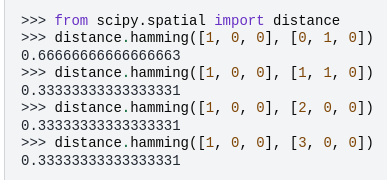

In [16]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = LOF(metric='hamming', contamination=0.05)
    model.fit(df)
    outliers["lof_hamming"] = model.predict(df)
    proba["lof_hamming"] = model.predict_proba(df)[:,1]


## Linear or PCA based

Principal component analysis (PCA) can be used in detecting outliers. PCA is a linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space.

In this procedure, covariance matrix of the data can be decomposed to orthogonal vectors, called eigenvectors, associated with eigenvalues. The eigenvectors with high eigenvalues capture most of the variance in the data.

Therefore, a low dimensional hyperplane constructed by k eigenvectors can capture most of the variance in the data. However, outliers are different from normal data points, which is more obvious on the hyperplane constructed by the eigenvectors with small eigenvalues.

Therefore, outlier scores can be obtained as the sum of the projected distance of a sample on all eigenvectors.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: Load a dataset (replace with your own dataset)
X = df

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: Fit PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [18]:
# Step 2: Calculate cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
cumulative_variance



array([0.12586695, 0.20426976, 0.28055148, 0.35380704, 0.42367896,
       0.4920788 , 0.55858522, 0.62235279, 0.68448865, 0.74579917,
       0.7985956 , 0.80990908, 0.81522424, 0.82000109, 0.82380325,
       0.82736027, 0.83013121, 0.83267335, 0.83468188, 0.83654206,
       0.83835456, 0.83995897, 0.84149525, 0.842995  , 0.84447229,
       0.84592959, 0.84733122, 0.84841741, 0.8494392 , 0.85044325,
       0.85144001, 0.85236994, 0.8532711 , 0.85415533, 0.85502617,
       0.85589681, 0.85675169, 0.85758594, 0.85839907, 0.85921069,
       0.86001645, 0.8608046 , 0.86158037, 0.86234876, 0.86310447,
       0.86385152, 0.86457209, 0.86528675, 0.86599111, 0.8666891 ,
       0.86736943, 0.86804127, 0.86870897, 0.86936996, 0.87001241,
       0.87065293, 0.87128462, 0.87190845, 0.87252396, 0.87313518,
       0.87373863, 0.87434057, 0.8749333 , 0.87551816, 0.87610242,
       0.87667753, 0.87725098, 0.87781679, 0.87838219, 0.87894734,
       0.87951222, 0.88006592, 0.88061826, 0.88116949, 0.88171

In [19]:
explained_variance_ratio

array([1.25866950e-01, 7.84028071e-02, 7.62817261e-02, 7.32555597e-02,
       6.98719177e-02, 6.83998381e-02, 6.65064211e-02, 6.37675682e-02,
       6.21358581e-02, 6.13105215e-02, 5.27964330e-02, 1.13134763e-02,
       5.31515901e-03, 4.77685790e-03, 3.80215765e-03, 3.55701842e-03,
       2.77093794e-03, 2.54213885e-03, 2.00852894e-03, 1.86018301e-03,
       1.81249939e-03, 1.60441625e-03, 1.53627298e-03, 1.49974969e-03,
       1.47729226e-03, 1.45730339e-03, 1.40163134e-03, 1.08618494e-03,
       1.02179389e-03, 1.00405152e-03, 9.96755418e-04, 9.29935470e-04,
       9.01158097e-04, 8.84231297e-04, 8.70838620e-04, 8.70639758e-04,
       8.54876857e-04, 8.34245582e-04, 8.13134858e-04, 8.11617369e-04,
       8.05764096e-04, 7.88152027e-04, 7.75766081e-04, 7.68392426e-04,
       7.55705364e-04, 7.47047816e-04, 7.20572661e-04, 7.14657758e-04,
       7.04361074e-04, 6.97995990e-04, 6.80325311e-04, 6.71843800e-04,
       6.67696176e-04, 6.60989847e-04, 6.42456401e-04, 6.40514744e-04,
      

In [20]:
# Step 3: Find number of components that explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # Add 1 since index starts from 0

print(f"Number of components to explain 95% variance: {n_components_95}")
print("Explained variance ratio for each component:")
for i, var in enumerate(explained_variance_ratio, 1):
    print(f"PC-{i}: {var:.4f}")


Number of components to explain 95% variance: 256
Explained variance ratio for each component:
PC-1: 0.1259
PC-2: 0.0784
PC-3: 0.0763
PC-4: 0.0733
PC-5: 0.0699
PC-6: 0.0684
PC-7: 0.0665
PC-8: 0.0638
PC-9: 0.0621
PC-10: 0.0613
PC-11: 0.0528
PC-12: 0.0113
PC-13: 0.0053
PC-14: 0.0048
PC-15: 0.0038
PC-16: 0.0036
PC-17: 0.0028
PC-18: 0.0025
PC-19: 0.0020
PC-20: 0.0019
PC-21: 0.0018
PC-22: 0.0016
PC-23: 0.0015
PC-24: 0.0015
PC-25: 0.0015
PC-26: 0.0015
PC-27: 0.0014
PC-28: 0.0011
PC-29: 0.0010
PC-30: 0.0010
PC-31: 0.0010
PC-32: 0.0009
PC-33: 0.0009
PC-34: 0.0009
PC-35: 0.0009
PC-36: 0.0009
PC-37: 0.0009
PC-38: 0.0008
PC-39: 0.0008
PC-40: 0.0008
PC-41: 0.0008
PC-42: 0.0008
PC-43: 0.0008
PC-44: 0.0008
PC-45: 0.0008
PC-46: 0.0007
PC-47: 0.0007
PC-48: 0.0007
PC-49: 0.0007
PC-50: 0.0007
PC-51: 0.0007
PC-52: 0.0007
PC-53: 0.0007
PC-54: 0.0007
PC-55: 0.0006
PC-56: 0.0006
PC-57: 0.0006
PC-58: 0.0006
PC-59: 0.0006
PC-60: 0.0006
PC-61: 0.0006
PC-62: 0.0006
PC-63: 0.0006
PC-64: 0.0006
PC-65: 0.0006
PC-6

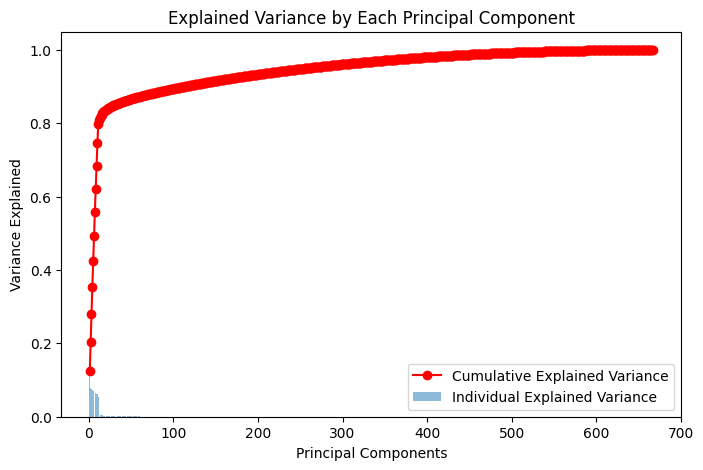

In [21]:

# Step 4: Plot explained variance for each component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, label="Individual Explained Variance")
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='r', label="Cumulative Explained Variance")
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.legend()
plt.show()



In [22]:
# Step 5: Use only the first `n_components_95` components
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)



In [23]:
# n_components_95

In [24]:
from pyod.models.pca import PCA as pyodPCA

In [25]:
model = pyodPCA(n_components=0.95, svd_solver="full", contamination=0.05)
model.fit(df)
outliers["pca"] = model.predict(df)
proba["pca"] = model.predict_proba(df)[:,1]
outliers["pca"]

array([1, 1, 1, ..., 0, 0, 0])

In [26]:
# copod = COPOD(contamination=0.05)
# copod.fit(df)

In [27]:
# outliers["copod"] = copod.predict(df)

In [28]:
# minimum 55 min
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05)
    model.fit(df)
    outliers["knn"] = model.predict(df)
    proba["knn_largest_8"] = model.predict_proba(df)[:,1]
    outliers["knn"]

In [29]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, method='average')
    model.fit(df)
    outliers["knn_average"] = model.predict(df)
    proba["knn_average"] = model.predict_proba(df)[:,1]
    outliers["knn_average"]

In [30]:
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, n_neighbors=8)
    model.fit(df)
    outliers["knn_largest_8"] = model.predict(df)
    proba["knn_largest_8"] = model.predict_proba(df)[:,1]
    outliers["knn_largest_8"]

In [31]:
model = IForest(contamination=0.05)
model.fit(df)
outliers["iforest"] = model.predict(df)
proba["iforest"] = model.predict_proba(df)[:,1]
outliers["iforest"]

/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 1])

In [32]:
model = IForest(contamination=0.05, n_estimators=256, max_samples=8192, max_features=0.33)
model.fit(df)
outliers["iforest_big"] = model.predict(df)
proba["iforest_big"] = model.predict_proba(df)[:,1]
outliers["iforest_big"]

/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 1])

In [33]:
model = DIF(contamination=0.05)
model.fit(df)
outliers["deep_iforest"] = model.predict(df)
proba["deep_iforest"] = model.predict_proba(df)[:,1]
outliers["deep_iforest"]

array([1, 0, 0, ..., 0, 0, 0])

## Wanna try-out
 
- ABOD (Angle based outlier detection) or FastABOD
- COPOD
- KNN
- IForest


In [67]:
outliers

{'lof': array([1, 1, 1, ..., 0, 0, 0]),
 'pca': array([1, 1, 1, ..., 0, 0, 0]),
 'iforest': array([0, 0, 0, ..., 0, 0, 1]),
 'iforest_big': array([0, 0, 0, ..., 0, 0, 1]),
 'deep_iforest': array([1, 0, 0, ..., 0, 0, 0])}

In [68]:
df_outliers = pd.DataFrame(outliers)
columns = df_outliers.columns
df_outliers['count'] =  df_outliers.sum(axis=1)
df_outliers['pyod % outlier'] = df_outliers['count'] / len(columns)
df_outliers

,lof,pca,iforest,iforest_big,deep_iforest,count,pyod % outlier
0,1,1,0,0,1,3,0.6
1,1,1,0,0,0,2,0.4
2,1,1,0,0,0,2,0.4
3,1,1,0,1,1,4,0.8
4,1,1,0,1,0,3,0.6
...,...,...,...,...,...,...,...
160062,0,0,0,0,0,0,0.0
160063,0,0,0,0,0,0,0.0
160064,0,0,0,0,0,0,0.0
160065,0,0,0,0,0,0,0.0


In [69]:
df_outliers['count'].value_counts()

count
0    140146
1     10995
4      3365
2      2757
3      2707
5        97
Name: count, dtype: int64

In [70]:
df_outliers["anomalie"] = (df_outliers['pyod % outlier'] > TRESHOLD_pyod_majority_vote).astype(int)
df_outliers

,lof,pca,iforest,iforest_big,deep_iforest,count,pyod % outlier,anomalie
0,1,1,0,0,1,3,0.6,0
1,1,1,0,0,0,2,0.4,0
2,1,1,0,0,0,2,0.4,0
3,1,1,0,1,1,4,0.8,1
4,1,1,0,1,0,3,0.6,0
...,...,...,...,...,...,...,...,...
160062,0,0,0,0,0,0,0.0,0
160063,0,0,0,0,0,0,0.0,0
160064,0,0,0,0,0,0,0.0,0
160065,0,0,0,0,0,0,0.0,0


In [71]:
df_outliers.to_csv("pyod.csv", index=False)

In [72]:
outliers

{'lof': array([1, 1, 1, ..., 0, 0, 0]),
 'pca': array([1, 1, 1, ..., 0, 0, 0]),
 'iforest': array([0, 0, 0, ..., 0, 0, 1]),
 'iforest_big': array([0, 0, 0, ..., 0, 0, 1]),
 'deep_iforest': array([1, 0, 0, ..., 0, 0, 0])}

In [73]:
proba

{'lof': array([1.33898710e-04, 4.31228581e-05, 6.00326797e-05, ...,
        5.06492856e-06, 1.79656951e-05, 1.87487425e-05]),
 'pca': array([0.03501065, 0.03678667, 0.03568456, ..., 0.00644684, 0.00683599,
        0.01494177]),
 'iforest': array([0.191469  , 0.35372062, 0.27078397, ..., 0.20196505, 0.33756649,
        0.46632579]),
 'iforest_big': array([0.13226247, 0.26679132, 0.19292179, ..., 0.13327384, 0.16213971,
        0.29573258]),
 'deep_iforest': array([0.71873336, 0.47642436, 0.52138686, ..., 0.49983062, 0.42255777,
        0.37072423])}

In [74]:
df_proba = pd.DataFrame(proba)
df_proba["avg"] = df_proba.sum(axis=1)
df_proba.sort_values("avg")

,lof,pca,iforest,iforest_big,deep_iforest,avg
109922,0.000004,0.004576,0.031164,0.099317,0.000000,0.135061
67331,0.000003,0.003800,0.050544,0.083377,0.028214,0.165937
147711,0.000004,0.003937,0.039637,0.084314,0.055375,0.183268
54663,0.000002,0.001994,0.020332,0.086950,0.076860,0.186139
33426,0.000003,0.004471,0.020447,0.088986,0.072870,0.186776
...,...,...,...,...,...,...
130847,0.000005,0.792841,0.090436,0.966853,0.755200,2.605335
133087,0.000007,0.731013,0.087925,0.922482,0.867001,2.608427
130643,0.000005,0.782163,0.074415,0.976355,0.775921,2.608858
64099,0.000004,0.784007,0.090436,0.989673,0.755202,2.619322
